Name: Prajakta Mahangare Roll No: 34 PRN NO.: 12520047 Class: CSE(AI)-SEDA Batch: B2

Assignment No.: 5.Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('uber.csv')
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [ ]:
df.describe

<bound method NDFrame.describe of         Unnamed: 0                            key  fare_amount  \
0         24238194    2015-05-07 19:52:06.0000003          7.5   
1         27835199    2009-07-17 20:04:56.0000002          7.7   
2         44984355   2009-08-24 21:45:00.00000061         12.9   
3         25894730    2009-06-26 08:22:21.0000001          5.3   
4         17610152  2014-08-28 17:47:00.000000188         16.0   
...            ...                            ...          ...   
199995    42598914   2012-10-28 10:49:00.00000053          3.0   
199996    16382965    2014-03-14 01:09:00.0000008          7.5   
199997    27804658   2009-06-29 00:42:00.00000078         30.9   
199998    20259894    2015-05-20 14:56:25.0000004         14.5   
199999    11951496   2010-05-15 04:08:00.00000076         14.1   

                pickup_datetime  pickup_longitude  pickup_latitude  \
0       2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1       2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2       2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3       2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4       2014-08-28 17:47:00 UTC        -73.925023        40.744085   
...                         ...               ...              ...   
199995  2012-10-28 10:49:00 UTC        -73.987042        40.739367   
199996  2014-03-14 01:09:00 UTC        -73.984722        40.736837   
199997  2009-06-29 00:42:00 UTC        -73.986017        40.756487   
199998  2015-05-20 14:56:25 UTC        -73.997124        40.725452   
199999  2010-05-15 04:08:00 UTC        -73.984395        40.720077   

        dropoff_longitude  dropoff_latitude  passenger_count  
0              -73.999512         40.723217                1  
1              -73.994710         40.750325                1  
2              -73.962565         40.772647                1  
3              -73.965316         40.803349                3  
4              -73.973082         40.761247                5  
...                   ...               ...              ...  
199995         -73.986525         40.740297                1  
199996         -74.006672         40.739620                1  
199997         -73.858957         40.692588                2  
199998         -73.983215         40.695415                1  
199999         -73.985508         40.768793                1  

[200000 rows x 9 columns]>

In [ ]:
df=df.dropna()

In [ ]:
df = df.drop(['Unnamed: 0', 'key'], axis=1)


In [ ]:
print(df.isnull().sum())

df = df.dropna()


fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour

df = df.drop('pickup_datetime', axis=1)


In [ ]:
df=df[df['fare_amount']>0]

In [ ]:
df=df[df['passenger_count']>0]

In [ ]:
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


Outlier Detection(Box Plot)

To identify and remove extreme fare values using box plot and IQR method.

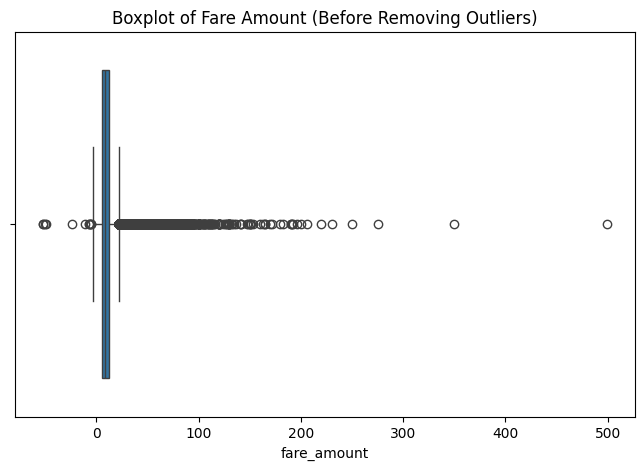

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare_amount'])
plt.title("Boxplot of Fare Amount (Before Removing Outliers)")
plt.show()

Removing Outliers

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 6.0
Q3: 12.5
IQR: 6.5


In [ ]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Lower Limit: -3.75
Upper Limit: 22.25


In [ ]:
df = df[(df['fare_amount'] >= lower_limit) &
        (df['fare_amount'] <= upper_limit)]

print("Shape After Removing Outliers:", df.shape)


Shape After Removing Outliers: (182833, 10)


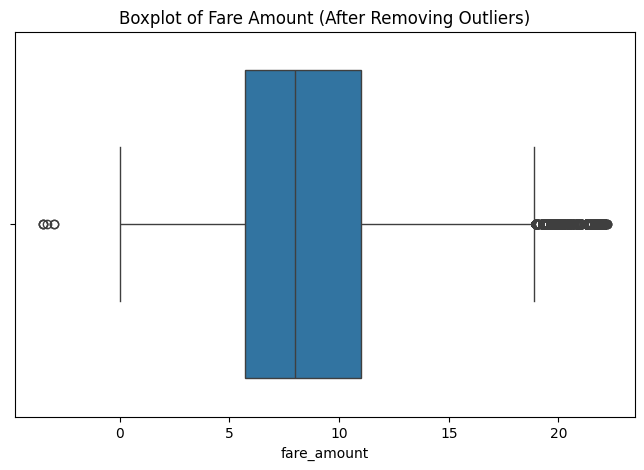

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare_amount'])
plt.title("Boxplot of Fare Amount (After Removing Outliers)")
plt.show()


Correlation Analysis

Pearson Correlation

In [ ]:
print("Pearson Correlation:")
print(df.corr(method='pearson'))


Pearson Correlation:
                   fare_amount  pickup_longitude  pickup_latitude  \
fare_amount           1.000000          0.000367         0.002618   
pickup_longitude      0.000367          1.000000        -0.812047   
pickup_latitude       0.002618         -0.812047         1.000000   
dropoff_longitude    -0.002413          0.835950        -0.767103   
dropoff_latitude      0.000589         -0.850574         0.684558   
passenger_count       0.012618         -0.000751        -0.001604   
year                  0.135172          0.009779        -0.009827   
month                 0.026338         -0.003949         0.004153   
day                   0.006860          0.003144        -0.006687   
hour                 -0.013219          0.003544        -0.004675   

                   dropoff_longitude  dropoff_latitude  passenger_count  \
fare_amount                -0.002413          0.000589         0.012618   
pickup_longitude            0.835950         -0.850574        -0.0007

In [ ]:
df.corr(method='pearson')

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
fare_amount,1.000000,0.000367,0.002618,-0.002413,0.000589,0.012618,0.135172,0.026338,0.006860,-0.013219
pickup_longitude,0.000367,1.000000,-0.812047,0.835950,-0.850574,-0.000751,0.009779,-0.003949,0.003144,0.003544
pickup_latitude,0.002618,-0.812047,1.000000,-0.767103,0.684558,-0.001604,-0.009827,0.004153,-0.006687,-0.004675
dropoff_longitude,-0.002413,0.835950,-0.767103,1.000000,-0.913949,0.000203,0.007415,-0.003472,0.003734,0.004026
dropoff_latitude,0.000589,-0.850574,0.684558,-0.913949,1.000000,-0.000853,-0.010038,0.003509,-0.006007,-0.003166
passenger_count,0.012618,-0.000751,-0.001604,0.000203,-0.000853,1.000000,0.002383,0.009607,0.003472,0.013435
year,0.135172,0.009779,-0.009827,0.007415,-0.010038,0.002383,1.000000,-0.115996,-0.010556,0.003119
month,0.026338,-0.003949,0.004153,-0.003472,0.003509,0.009607,-0.115996,1.000000,-0.016254,-0.002705
day,0.006860,0.003144,-0.006687,0.003734,-0.006007,0.003472,-0.010556,-0.016254,1.000000,0.005106
hour,-0.013219,0.003544,-0.004675,0.004026,-0.003166,0.013435,0.003119,-0.002705,0.005106,1.000000


Spearman Correlation

In [ ]:
print("Spearman Correlation:")
print(df.corr(method='spearman'))


Spearman Correlation:
                   fare_amount  pickup_longitude  pickup_latitude  \
fare_amount           1.000000         -0.046405        -0.070594   
pickup_longitude     -0.046405          1.000000         0.572975   
pickup_latitude      -0.070594          0.572975         1.000000   
dropoff_longitude     0.022307          0.457223         0.252491   
dropoff_latitude     -0.073340          0.278426         0.563124   
passenger_count       0.020764         -0.020494        -0.015185   
year                  0.137338         -0.000497        -0.005464   
month                 0.027229         -0.003666         0.000542   
day                   0.005905         -0.004376        -0.001675   
hour                  0.005230         -0.007571         0.010726   

                   dropoff_longitude  dropoff_latitude  passenger_count  \
fare_amount                 0.022307         -0.073340         0.020764   
pickup_longitude            0.457223          0.278426        -0.020

In [ ]:
df.corr(method='spearman')

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
fare_amount,1.000000,-0.046405,-0.070594,0.022307,-0.073340,0.020764,0.137338,0.027229,0.005905,0.005230
pickup_longitude,-0.046405,1.000000,0.572975,0.457223,0.278426,-0.020494,-0.000497,-0.003666,-0.004376,-0.007571
pickup_latitude,-0.070594,0.572975,1.000000,0.252491,0.563124,-0.015185,-0.005464,0.000542,-0.001675,0.010726
dropoff_longitude,0.022307,0.457223,0.252491,1.000000,0.520083,-0.017477,0.001580,-0.003352,-0.008702,-0.021604
dropoff_latitude,-0.073340,0.278426,0.563124,0.520083,1.000000,-0.010073,-0.001387,-0.000361,-0.005221,0.002537
passenger_count,0.020764,-0.020494,-0.015185,-0.017477,-0.010073,1.000000,-0.015029,0.009590,0.001966,0.037392
year,0.137338,-0.000497,-0.005464,0.001580,-0.001387,-0.015029,1.000000,-0.107956,-0.010471,0.003115
month,0.027229,-0.003666,0.000542,-0.003352,-0.000361,0.009590,-0.107956,1.000000,-0.015981,-0.001568
day,0.005905,-0.004376,-0.001675,-0.008702,-0.005221,0.001966,-0.010471,-0.015981,1.000000,0.006189
hour,0.005230,-0.007571,0.010726,-0.021604,0.002537,0.037392,0.003115,-0.001568,0.006189,1.000000


Kendall Correlation

In [ ]:
print("Kendall Correlation:")
print(df.corr(method='kendall'))


Kendall Correlation:
                   fare_amount  pickup_longitude  pickup_latitude  \
fare_amount           1.000000         -0.031958        -0.048200   
pickup_longitude     -0.031958          1.000000         0.433767   
pickup_latitude      -0.048200          0.433767         1.000000   
dropoff_longitude     0.014453          0.321582         0.178338   
dropoff_latitude     -0.049949          0.195584         0.404481   
passenger_count       0.016274         -0.015909        -0.011780   
year                  0.099415         -0.000350        -0.003897   
month                 0.019110         -0.002545         0.000379   
day                   0.004048         -0.002965        -0.001135   
hour                  0.003821         -0.006178         0.006883   

                   dropoff_longitude  dropoff_latitude  passenger_count  \
fare_amount                 0.014453         -0.049949         0.016274   
pickup_longitude            0.321582          0.195584        -0.0159

In [ ]:
df.corr(method='kendall')

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
fare_amount,1.000000,-0.031958,-0.048200,0.014453,-0.049949,0.016274,0.099415,0.019110,0.004048,0.003821
pickup_longitude,-0.031958,1.000000,0.433767,0.321582,0.195584,-0.015909,-0.000350,-0.002545,-0.002965,-0.006178
pickup_latitude,-0.048200,0.433767,1.000000,0.178338,0.404481,-0.011780,-0.003897,0.000379,-0.001135,0.006883
dropoff_longitude,0.014453,0.321582,0.178338,1.000000,0.399505,-0.013535,0.001128,-0.002324,-0.005893,-0.014710
dropoff_latitude,-0.049949,0.195584,0.404481,0.399505,1.000000,-0.007812,-0.000990,-0.000249,-0.003549,0.002455
passenger_count,0.016274,-0.015909,-0.011780,-0.013535,-0.007812,1.000000,-0.012446,0.007742,0.001546,0.029677
year,0.099415,-0.000350,-0.003897,0.001128,-0.000990,-0.012446,1.000000,-0.080245,-0.007608,0.002282
month,0.019110,-0.002545,0.000379,-0.002324,-0.000249,0.007742,-0.080245,1.000000,-0.011250,-0.001111
day,0.004048,-0.002965,-0.001135,-0.005893,-0.003549,0.001546,-0.007608,-0.011250,1.000000,0.004291
hour,0.003821,-0.006178,0.006883,-0.014710,0.002455,0.029677,0.002282,-0.001111,0.004291,1.000000


Correlation Heatmap

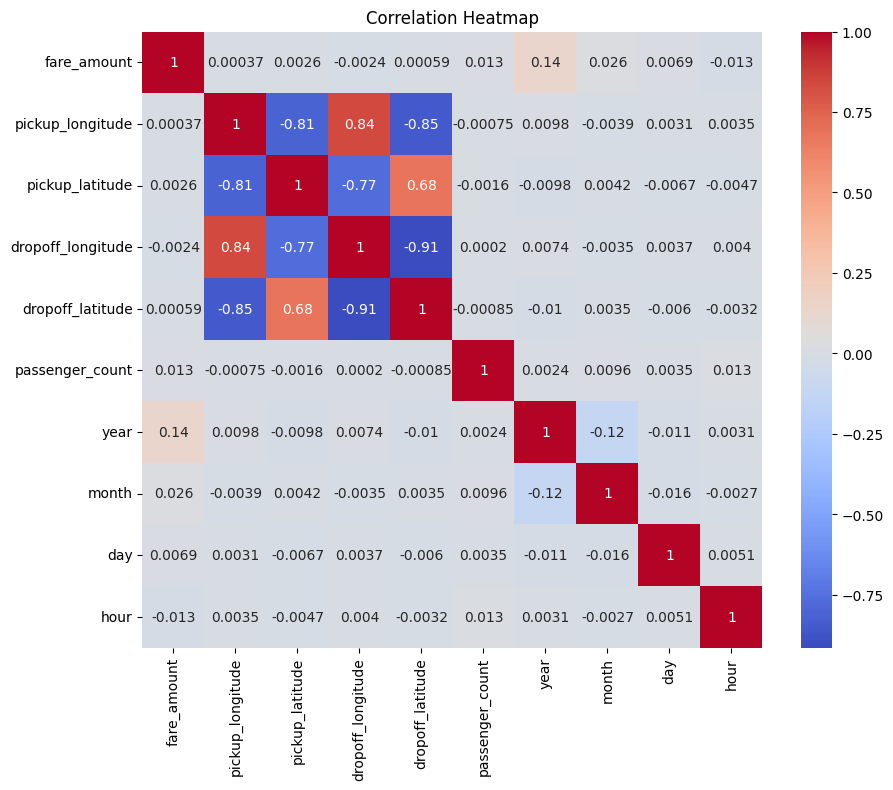

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Define Features & Target

In [ ]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']


Feature Selection and Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (146266, 9)
X_test shape: (36567, 9)


Linear Regression Model

This step predicts Uber fare values using a linear relationship between input features and fare amount.

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Intercept:", linear_model.intercept_)
print("Linear Coefficients:", linear_model.coef_)


Linear Intercept: -617.6175641241523
Linear Coefficients: [ 0.00368073  0.00408642 -0.00178954  0.00074413  0.0409431   0.31126962
  0.0518002   0.00337793 -0.00942936]


Ridge Regression Model

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)


Lasso Regression Model

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)


Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

# Ridge
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Linear Regression")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R2  :", r2_linear)

print("\nRidge Regression")
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2  :", r2_ridge)

print("\nLasso Regression")
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2  :", r2_lasso)


Linear Regression
MAE : 3.2412899460928712
MSE : 16.746772816658687
RMSE: 4.0922821037483095
R2  : 0.02140512204502032

Ridge Regression
MAE : 3.2412899660844694
MSE : 16.746772848703696
RMSE: 4.092282107663607
R2  : 0.021405120172475645

Lasso Regression
MAE : 3.242968491465658
MSE : 16.75473400263168
RMSE: 4.093254695548724
R2  : 0.020939911469770478


In [ ]:
plot_df = X_test.copy()
plot_df['Actual_Fare'] = y_test
plot_df['Linear_Pred'] = y_pred_linear
plot_df['Ridge_Pred'] = y_pred_ridge
plot_df['Lasso_Pred'] = y_pred_lasso

plot_df = plot_df.sort_values('passenger_count')


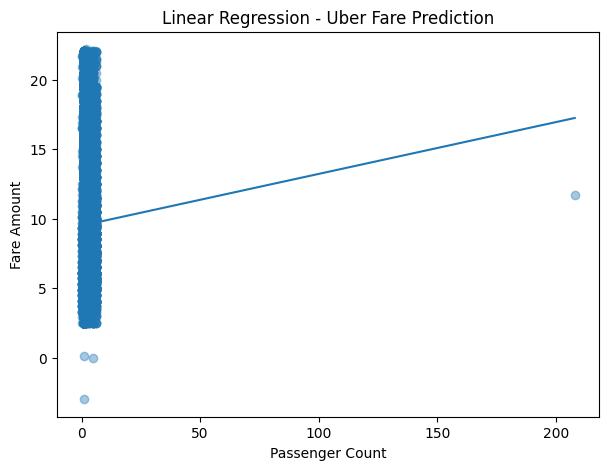

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(plot_df['passenger_count'],
            plot_df['Actual_Fare'],
            alpha=0.4)

plt.plot(plot_df['passenger_count'],
         plot_df['Linear_Pred'])

plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.title("Linear Regression - Uber Fare Prediction")
plt.show()


In [ ]:
import pandas as pd

data = {
    'Hours_Studied': [2, 4, 6, 8, 10, 12, 14, 16],
    'Marks': [50, 55, 65, 75, 85, 90, 95, 100]
}

df = pd.DataFrame(data)
df


,Hours_Studied,Marks
0,2,50
1,4,55
2,6,65
3,8,75
4,10,85
5,12,90
6,14,95
7,16,100


In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours_Studied  8 non-null      int64
 1   Marks          8 non-null      int64
dtypes: int64(2)
memory usage: 260.0 bytes


,0
Hours_Studied,0
Marks,0


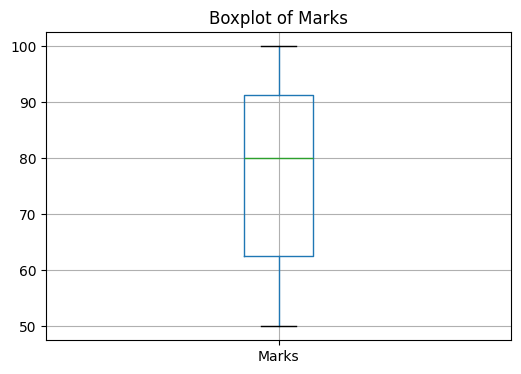

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df.boxplot(column=['Marks'])
plt.title("Boxplot of Marks")
plt.show()


In [ ]:
df.corr(method='pearson')


,Hours_Studied,Marks
Hours_Studied,1.000000,0.990406
Marks,0.990406,1.000000


In [ ]:
df.corr(method='spearman')


,Hours_Studied,Marks
Hours_Studied,1.0,1.0
Marks,1.0,1.0


In [ ]:
df.corr(method='kendall')


,Hours_Studied,Marks
Hours_Studied,1.0,1.0
Marks,1.0,1.0


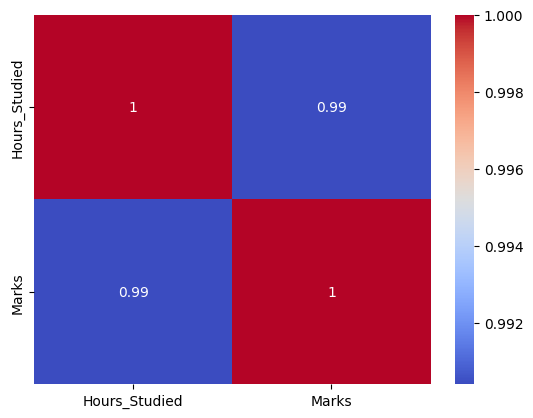

In [ ]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [ ]:
X = df[['Hours_Studied']]
y = df['Marks']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)


In [ ]:
print("Intercept:", linear_model.intercept_)
print("Slope:", linear_model.coef_[0])


Intercept: 44.50000000000001
Slope: 3.6249999999999982


In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)


In [ ]:
print("Ridge Intercept:", ridge_model.intercept_)
print("Ridge Coefficient:", ridge_model.coef_[0])


Ridge Intercept: 44.75186104218362
Ridge Coefficient: 3.5980148883374685
